# 2026-10-09 Intro aperture photometry: SN 2026aaiv in NGC 7331

## Overview

+ Reason through "tricky" aspects of counting pixels
+ Think about how to separate starlight from background
+ This time use a *real* image: our B image of the supernova SN 2026aaiv in NGC 7331

## The image and the supernova

SN 2026aaiv is a Type Ia supernova in the galaxy NGC 7331. It was discovered by the ATLAS survey on September 1, 2026, and we took images of NGC 7331 on the night of September 8 (early September 9 UT). Reports collected on the [Rochester Astronomy supernova page](https://rochesterastronomy.org/sn2026/sn2026aaiv.html) put it near magnitude 13 on September 9, a week into its rise. It peaked near magnitude 12 in mid-September and has been fading since.

The image below is our calibrated (bias, dark, flat) 120 second B image. The position of the supernova reported to the Transient Name Server (TNS) is used, along with the WCS in the image header, to find the supernova in the image. We then cut out small 25 by 25 pixel pieces of the image, the same size as the 25 by 25 fake images in the aperture-size notes, and look at the pixel values one by one.

In [1]:
import warnings

from astropy.io import fits
from astropy.wcs import WCS, FITSFixedWarning
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.modeling.models import Gaussian2D
from astropy.stats import gaussian_sigma_to_fwhm
from astropy.visualization import simple_norm

from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle

import numpy as np

from photutils.profiles import RadialProfile, CurveOfGrowth

warnings.filterwarnings('ignore', category=FITSFixedWarning)

In [2]:
def image_with_pixels_labeled(image, pix_precision=0, center_dots=True, ax=None, fig=None, **text_kwargs):
    image_size = image.shape[0]
    if ax is None:
        ax = plt.gca()
    if fig is not None:
        fig = plt.gcf()
    ima = ax.imshow(image)
    if fig is not None:
        fig.colorbar(ima, ax=ax)
    number_format = '{:.' + f'{pix_precision:d}' + 'f}'
    for i in range(image_size):
        for j in range(image_size):
            ax.text(i, j, number_format.format(image[j, i]),
                     fontweight='bold',
                     horizontalalignment='center',
                     verticalalignment='center',
                     **text_kwargs
                    )
            if center_dots:
                ax.scatter(i, j, marker='.', c='red', alpha=0.5)


In [3]:
def circle(x, y, radius):
    angle = np.linspace(0, 2 * np.pi)
    return x + radius * np.cos(angle), y + radius * np.sin(angle)

## Load the image and find the supernova

In [4]:
image_file = '/calibrated/2026-09-08-calibrated/reduced/NGC7331-S001-R004-C001-B.fit'
#'NGC7331-S001-R004-C001-B.fit'

data = fits.getdata(image_file)
header = fits.getheader(image_file)
wcs = WCS(header)

print(header['OBJECT'], header['FILTER'], header['EXPOSURE'], 's', header['DATE-OBS'])

ngc 7331 B 120.0 s 2026-09-09T07:02:59.579


In [5]:
# Position of SN 2026aaiv from the Transient Name Server
sn_coord = SkyCoord('22h37m05.628s', '+34d24m35.19s', frame='icrs')

sn_x, sn_y = wcs.world_to_pixel(sn_coord)
sn_x = int(round(float(sn_x)))
sn_y = int(round(float(sn_y)))
print(f'Supernova is at pixel x={sn_x}, y={sn_y}')

Supernova is at pixel x=2074, y=2097


In [6]:
figure_size = (20, 20)
graph_size = (10, 10)
image_size = 25
star_center = (12, 12)

half = image_size // 2

# 25 x 25 piece of the image centered on the supernova
sn_cutout = data[sn_y - half:sn_y + half + 1, sn_x - half:sn_x + half + 1]

# 25 x 25 piece of the image with no stars and only a little galaxy light,
# centered 40 pixels to the right of the supernova and 40 pixels lower in y
# (lower y appears ABOVE the supernova in these plots, since imshow puts y=0 at the top).
# The offsets were chosen by looking at the image.
sky_x0 = sn_x + 40 - half
sky_y0 = sn_y - 40 - half
sky_patch = data[sky_y0:sky_y0 + image_size, sky_x0:sky_x0 + image_size]

print(f'Median of sky patch: {np.median(sky_patch):.1f}, standard deviation: {sky_patch.std():.1f}')

Median of sky patch: 17.7, standard deviation: 9.3


## Part 1: The galaxy and the supernova

Before zooming in to 25 by 25 pixel pieces, here is a larger piece of the image, 201 by 201 pixels (about 1.9 arcmin on a side) centered on the supernova. The galaxy NGC 7331 is much bigger than this, so only its nucleus and part of its disk fit. The color scale is logarithmic so that both the faint sky and the bright supernova are visible. The red box is the 25 by 25 pixel supernova cutout used below, and the orange box is the 25 by 25 pixel "sky" patch. The thin white lines mark the edges of individual pixels.

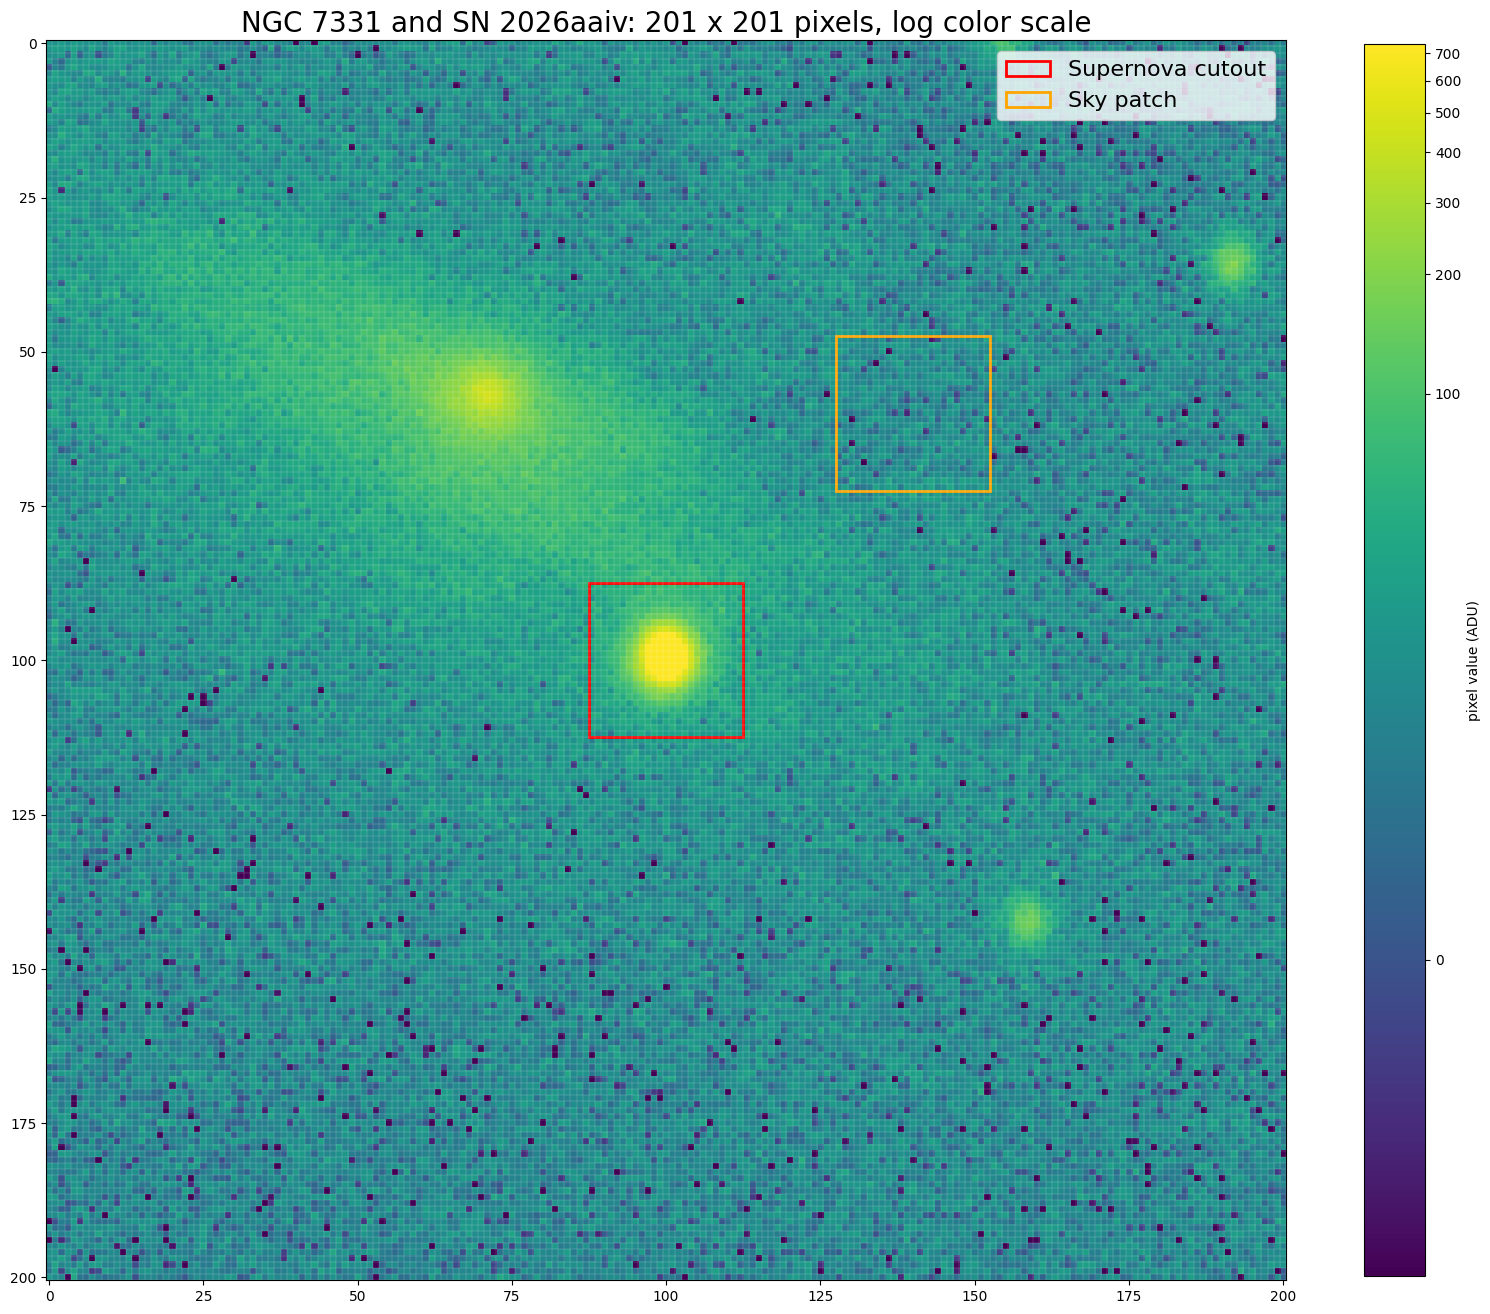

In [7]:
big_half = 100
big_cutout = data[sn_y - big_half:sn_y + big_half + 1, sn_x - big_half:sn_x + big_half + 1]

fig, ax = plt.subplots(figsize=figure_size)

# Log color scale so the sky, the galaxy and the supernova are all visible
norm = simple_norm(big_cutout, stretch='log',
                   vmin=np.percentile(big_cutout, 1), vmax=np.percentile(big_cutout, 99.9))
ima = ax.imshow(big_cutout, cmap='viridis', norm=norm, interpolation='none')
fig.colorbar(ima, ax=ax, label='pixel value (ADU)', shrink=0.8)

# Draw the pixel grid: a thin line at every pixel edge
ax.set_xticks(np.arange(-0.5, big_cutout.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, big_cutout.shape[0], 1), minor=True)
ax.grid(which='minor', color='white', linewidth=0.3, alpha=0.4)
ax.tick_params(which='minor', length=0)

# Outline the two 25 x 25 pieces of the image used in the rest of the notebook
ax.add_patch(Rectangle((big_half - half - 0.5, big_half - half - 0.5), image_size, image_size,
                       fill=False, edgecolor='red', linewidth=2, label='Supernova cutout'))
ax.add_patch(Rectangle((sky_x0 - (sn_x - big_half) - 0.5, sky_y0 - (sn_y - big_half) - 0.5),
                       image_size, image_size,
                       fill=False, edgecolor='orange', linewidth=2, label='Sky patch'))
ax.legend(loc='upper right', fontsize=16)
ax.set_title(f'NGC 7331 and SN 2026aaiv: {big_cutout.shape[1]} x {big_cutout.shape[0]} pixels, log color scale',
             fontsize=20);

In [9]:
circ = circle(*star_center, 4)

### Zoom in on supernova

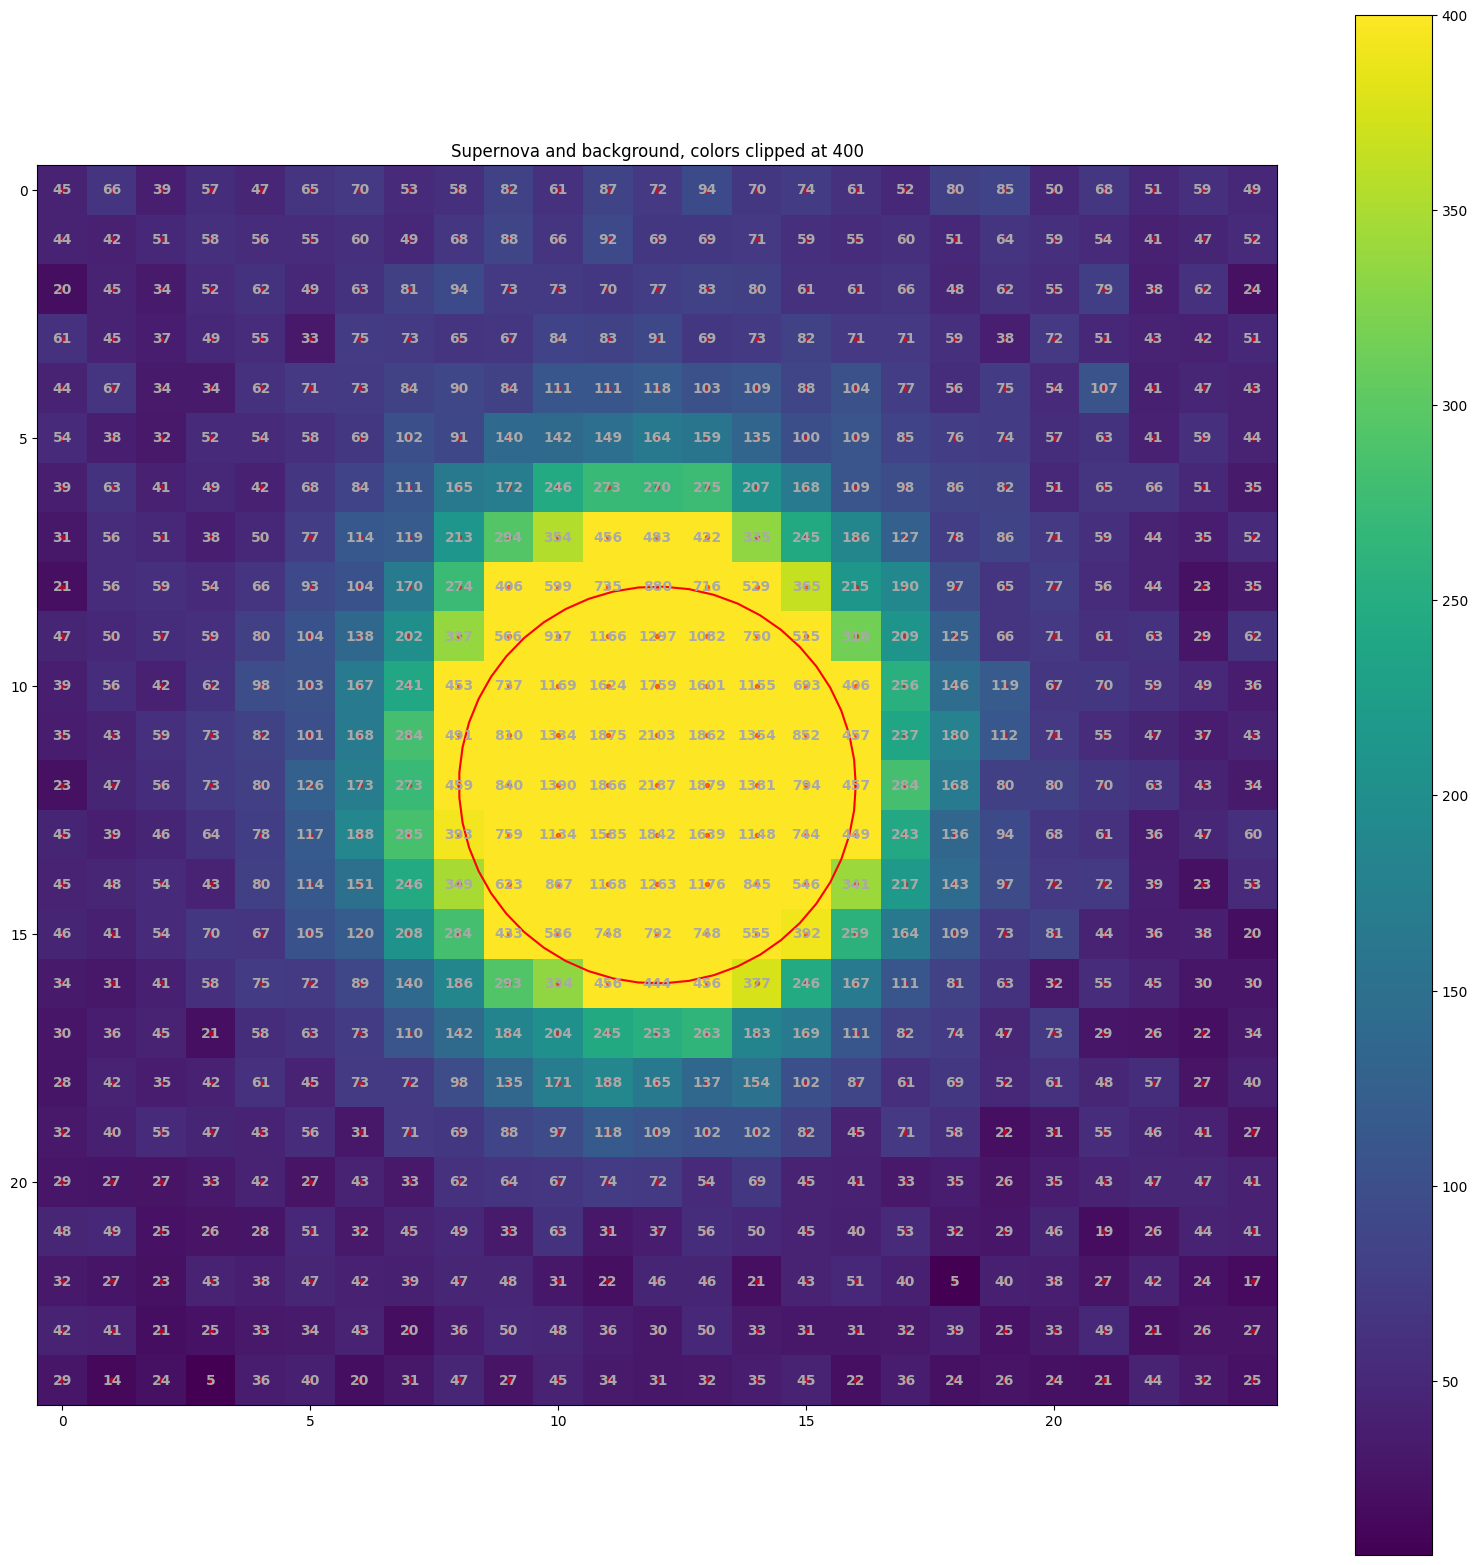

In [10]:
plt.figure(figsize=figure_size)

image_with_pixels_labeled(sn_cutout, fig=plt.gcf(), color='darkgray')
plt.gcf().axes[0].images[0].set_clim(vmax=400)
plt.title('Supernova and background, colors clipped at 400')
plt.plot(circ[0], circ[1], color='red');

### Zoom in on background (a piece of the real image near NGC 7331)

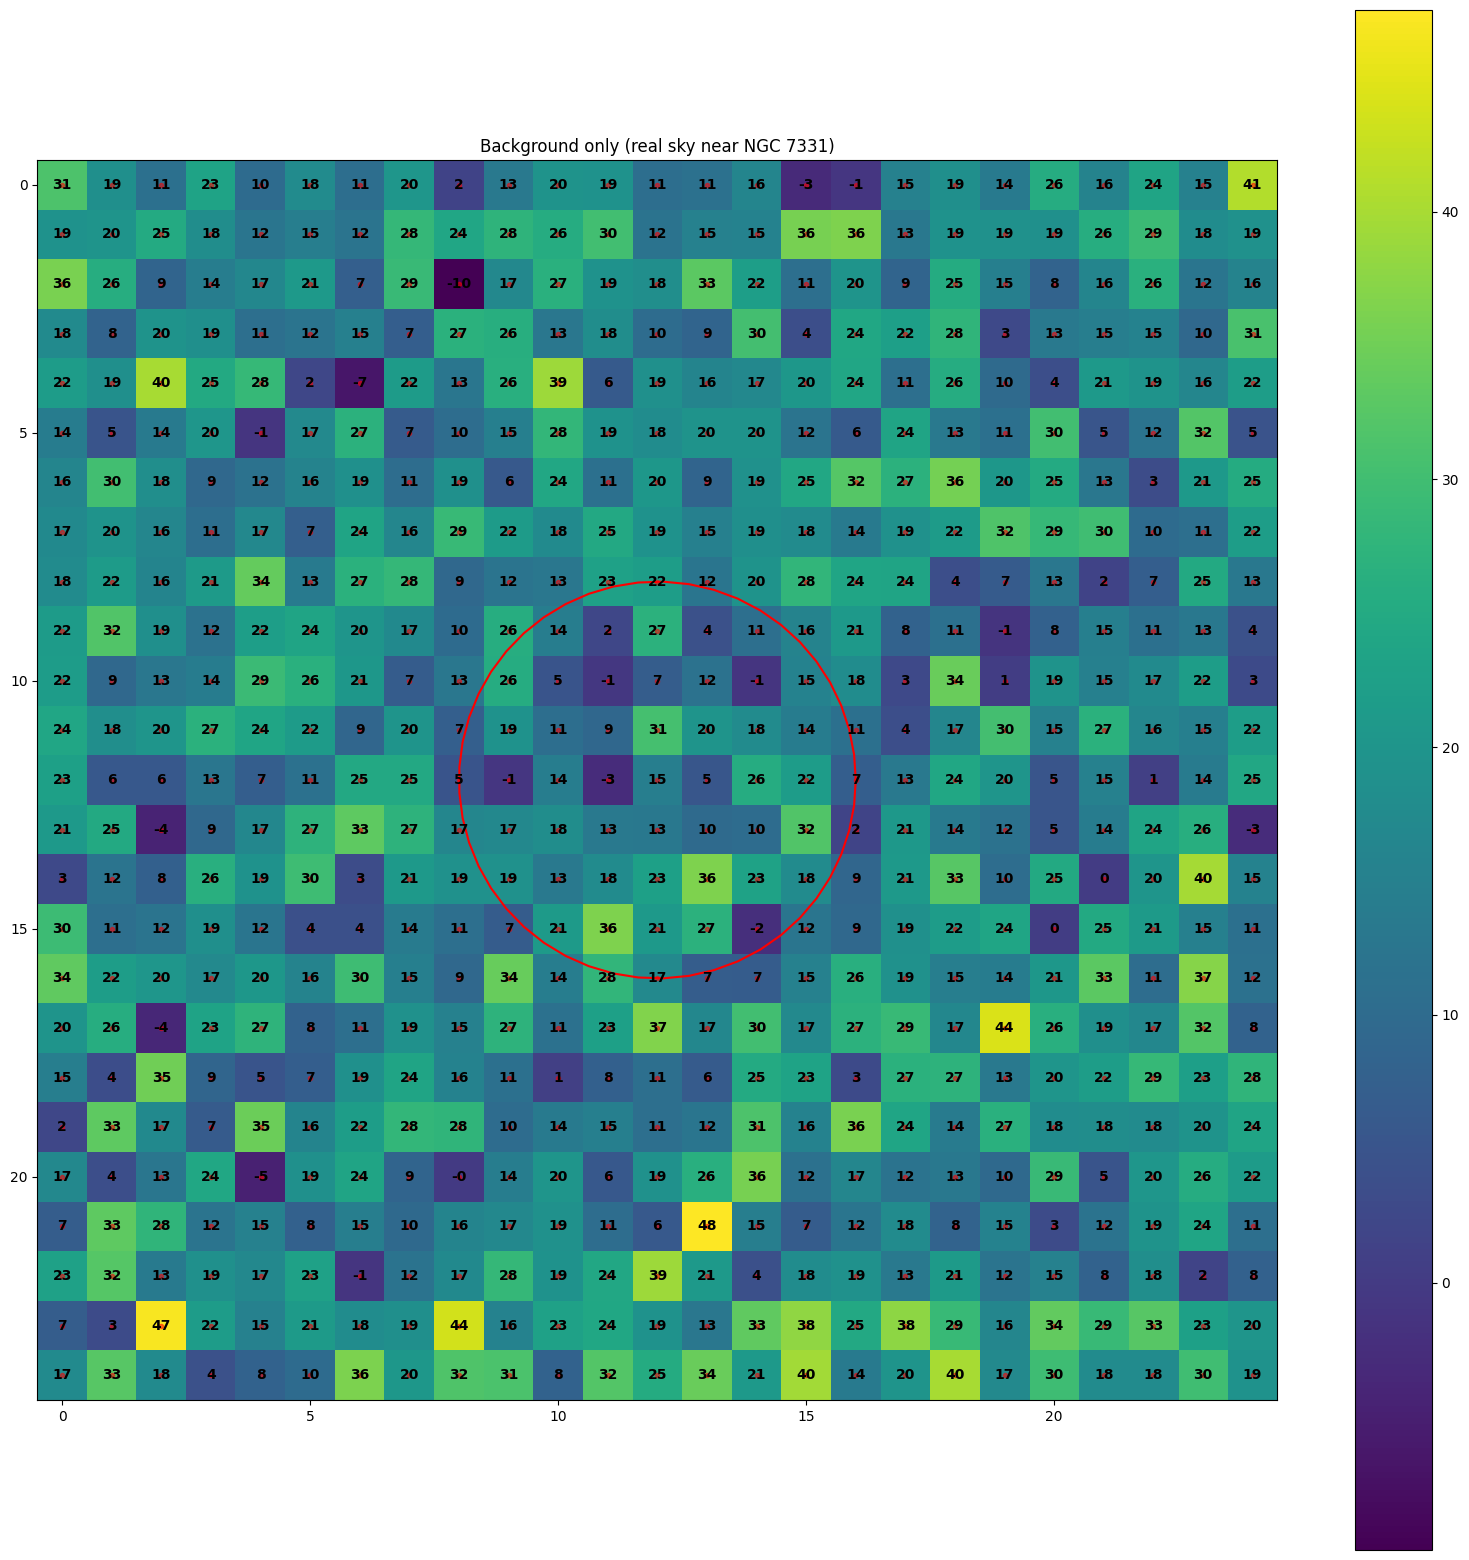

In [11]:
plt.figure(figsize=figure_size)

image_with_pixels_labeled(sky_patch, fig=plt.gcf(), color='black')
plt.title('Background only (real sky near NGC 7331)')
plt.plot(circ[0], circ[1], color='red');

## Part 2: Counting background with a fake image

In [13]:
rng = np.random.default_rng(seed=548975)

In [14]:
image_size = 10

background_image = rng.poisson(lam=200, size=[image_size, image_size])

In [15]:
def circle(x, y, radius):
    angle = np.linspace(0, 2 * np.pi)
    return x + radius * np.cos(angle), y + radius * np.sin(angle)

In [16]:
circ = circle(5, 5, 2.1)

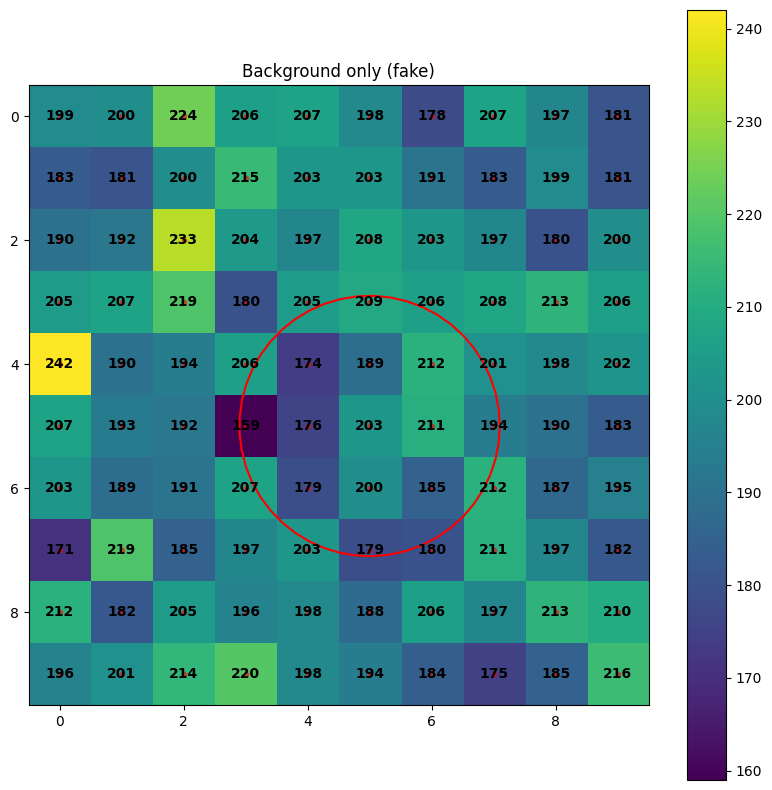

In [17]:
plt.figure(figsize=(10, 10))
plt.imshow(background_image)
plt.colorbar()
for i in range(image_size):
    for j in range(image_size):
        plt.text(i, j, int(background_image[j, i]), 
                 fontweight='bold',
                 color='black',
                 horizontalalignment='center',
                 verticalalignment='center')
        plt.scatter(i, j, marker='.', c='red', alpha=0.5)

plt.title("Background only (fake)")
plt.plot(circ[0], circ[1], color='red');
        

## Part 3: Now with a fake star....

In [7]:
star = Gaussian2D(amplitude=200, x_stddev=1.25, y_stddev=1.25)
grids = np.mgrid[0:10, 0:10]
star_grid = star(grids[0] - 5, grids[1] - 5)

In [8]:
total_image = background_image + star_grid

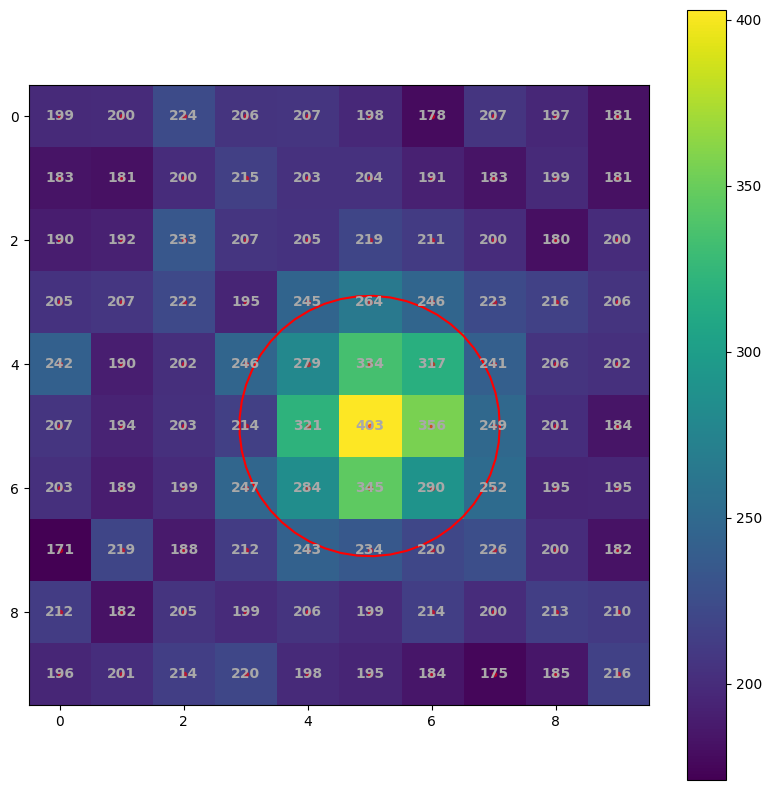

In [9]:
plt.figure(figsize=(10, 10))
plt.imshow(total_image)
plt.colorbar()
for i in range(image_size):
    for j in range(image_size):
        plt.text(i, j, int(total_image[j, i]), 
                 fontweight='bold',
                 color='darkgray',
                 horizontalalignment='center',
                 verticalalignment='center')
        plt.scatter(i, j, marker='.', c='red', alpha=0.5)

plt.plot(circ[0], circ[1], color='red');
        

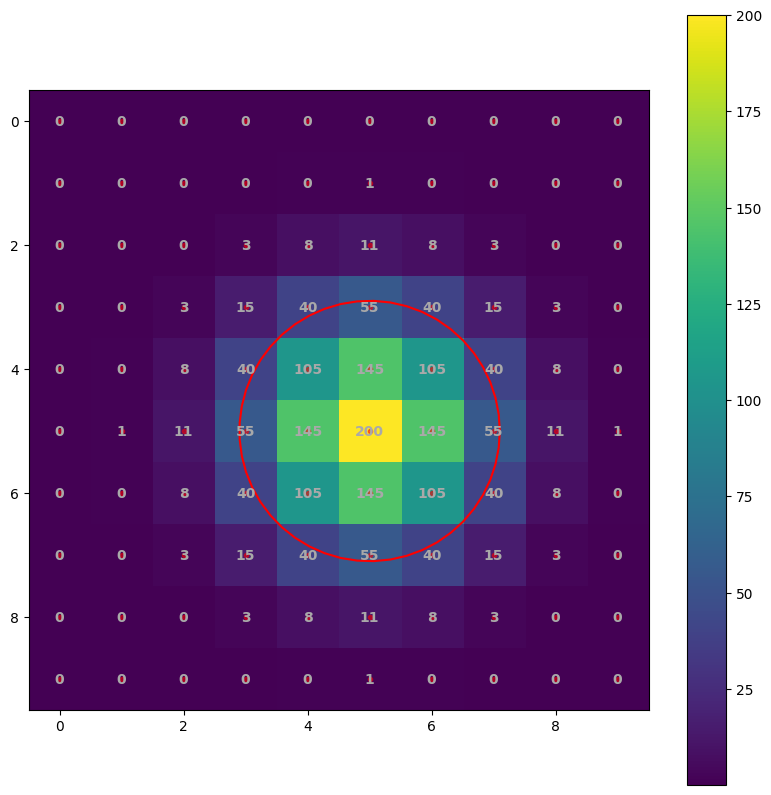

In [10]:
plt.figure(figsize=(10, 10))
plt.imshow(star_grid)
plt.colorbar()
for i in range(image_size):
    for j in range(image_size):
        plt.text(i, j, int(star_grid[j, i]), 
                 fontweight='bold',
                 color='darkgray',
                 horizontalalignment='center',
                 verticalalignment='center')
        plt.scatter(i, j, marker='.', c='red', alpha=0.5)

plt.plot(circ[0], circ[1], color='red');
     